# Federated Learning Engine

This notebook implements a **Federated Learning engine** with two modes:

| Mode | Description |
|------|-------------|
| **FedAvg** | Single global model, standard weighted aggregation |
| **EnsembleFL** | Each client trains its own architecture; inference uses soft-voting across all client models |

> Everything runs in-process (simulated FL on one machine).

In [ ]:
#!pip install import-ipynb

## 1. Imports

In [18]:
import copy
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Dict, List, Tuple, Optional
from collections import OrderedDict

import import_ipynb
from uci_har_federated import N_CLASSES, client_loaders, test_loader
from har_models import build_model

## 2. Device Configuration

In [10]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 3. Helper Utilities

Utility functions for extracting/loading model parameters and computing the **FedAvg** weighted average.

In [37]:
def get_params(model):
    return {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }


def set_params(model, params):
    model.load_state_dict(params, strict=True)


def fedavg(param_dicts, weights=None):
    if weights is None:
        weights = [1.0] * len(param_dicts)

    total = sum(weights)
    weights = [w / total for w in weights]

    avg = {}
    keys = param_dicts[0].keys()

    for k in keys:
        first = param_dicts[0][k]

        if first.dtype in (torch.int32, torch.int64):
            avg[k] = first.clone()
        else:
            avg[k] = sum(
                w * client[k]
                for w, client in zip(weights, param_dicts)
            )

    return avg

## 4. Local Training

Each client trains its model locally for `epochs` steps.  
An optional **Gaussian noise defense** can be applied to features before the forward pass.

In [12]:
def local_train(
    model:     nn.Module,
    loader:    DataLoader,
    epochs:    int   = 1,
    lr:        float = 1e-3,
    noise_std: float = 0.0,   # defense: Gaussian noise on features
) -> Tuple[nn.Module, float, int]:
    """
    Train a model on one client's local data.

    Args:
        model:     PyTorch model to train.
        loader:    DataLoader for this client's dataset.
        epochs:    Number of local epochs.
        lr:        Learning rate for Adam optimizer.
        noise_std: Std-dev of Gaussian noise added to input features (0 = disabled).

    Returns:
        (trained_model_cpu, avg_loss, n_samples)
    """
    model = model.to(DEVICE)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    total_loss, n = 0.0, 0

    for _ in range(epochs):
        for X, y_act, _ in loader:
            X, y_act = X.to(DEVICE), y_act.to(DEVICE)

            # ── defense: feature-level noise injection ──
            if noise_std > 0.0:
                X = X + torch.randn_like(X) * noise_std

            optimizer.zero_grad()
            logits = model(X)
            loss   = criterion(logits, y_act)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(X)
            n          += len(X)

    return model.cpu(), total_loss / n, n

## 5. FedAvg Server

Classic **FedAvg** — one shared model architecture aggregated each communication round.

In [13]:
class FedAvgServer:
    """
    Classic FedAvg server.

    One shared model architecture is trained collaboratively.
    Each round:
      1. A subset of clients receive the global model.
      2. Each client trains locally.
      3. Updated weights are aggregated back into the global model.
    """

    def __init__(self, arch: str = "mlp", seed: int = 42):
        torch.manual_seed(seed)
        self.global_model = build_model(arch)
        self.arch         = arch
        self.history: List[dict] = []   # [(round, act_acc, subj_acc, elapsed_s)]

    def run(
        self,
        client_loaders:    Dict[int, DataLoader],
        test_loader:       DataLoader,
        rounds:            int   = 20,
        clients_per_round: int   = 10,
        local_epochs:      int   = 2,
        lr:                float = 1e-3,
        noise_std:         float = 0.0,
        verbose:           bool  = True,
    ) -> List[dict]:
        """
        Run the FedAvg training loop.

        Args:
            client_loaders:    Dict mapping client ID → DataLoader.
            test_loader:       DataLoader for the held-out test set.
            rounds:            Total communication rounds.
            clients_per_round: How many clients participate each round.
            local_epochs:      Local training epochs per client per round.
            lr:                Learning rate.
            noise_std:         Input noise std for the feature-noise defense.
            verbose:           Print per-round metrics.

        Returns:
            Training history as a list of dicts.
        """
        client_ids = list(client_loaders.keys())

        for r in range(1, rounds + 1):
            t0 = time.time()

            # ── select clients ──
            selected = np.random.choice(
                client_ids,
                size=min(clients_per_round, len(client_ids)),
                replace=False,
            ).tolist()

            param_list, weights = [], []

            for cid in selected:
                local_model = copy.deepcopy(self.global_model)
                set_params(local_model, get_params(self.global_model))

                local_model, loss, n = local_train(
                    local_model, client_loaders[cid],
                    epochs=local_epochs, lr=lr, noise_std=noise_std,
                )
                param_list.append(get_params(local_model))
                weights.append(n)

            # ── aggregate ──
            avg_params = fedavg(param_list, weights)
            set_params(self.global_model, avg_params)

            # ── evaluate ──
            act_acc, subj_acc = evaluate(self.global_model, test_loader)

            elapsed = time.time() - t0
            record = {
                "round":     r,
                "act_acc":   act_acc,
                "subj_acc":  subj_acc,
                "elapsed_s": elapsed,
            }
            self.history.append(record)

            if verbose:
                print(
                    f"  [FedAvg] Round {r:3d}/{rounds} | "
                    f"act_acc={act_acc:.3f}  subj_acc={subj_acc:.3f} | "
                    f"{elapsed:.1f}s"
                )

        return self.history

## 6. Ensemble FL Server

> **Core novel contribution** of the project.

Each client is assigned a (possibly different) architecture.  
After training, **all** client models are kept.  
Inference = **soft-vote** (average softmax probabilities) across all client models.

In [21]:
class EnsembleFLServer:
    """
    Ensemble Federated Learning server.

    Each client is assigned a (possibly different) architecture via round-robin.
    After training, ALL client models are retained.
    Inference uses soft-voting (average softmax) across all client models.
    """

    def __init__(self, client_ids, arch_cycle=["mlp","cnn","lstm"], seed=42):
        torch.manual_seed(seed)
    
        self.client_ids = list(client_ids)
    
        self.client_archs = {
            cid: arch_cycle[i % len(arch_cycle)]
            for i, cid in enumerate(self.client_ids)
        }
    
        self.client_models = {
            cid: build_model(self.client_archs[cid])
            for cid in self.client_ids
        }
    
        self.history = []

    def run(
        self,
        client_loaders:    Dict[int, DataLoader],
        test_loader:       DataLoader,
        rounds:            int   = 20,
        clients_per_round: int   = 10,
        local_epochs:      int   = 2,
        lr:                float = 1e-3,
        noise_std:         float = 0.0,
        verbose:           bool  = True,
    ) -> List[dict]:
        """
        Run the EnsembleFL training loop.

        Unlike FedAvg, there is no aggregation step — each client model
        evolves independently; inference combines them all via soft voting.

        Args:
            client_loaders:    Dict mapping client ID → DataLoader.
            test_loader:       DataLoader for the held-out test set.
            rounds:            Total communication rounds.
            clients_per_round: How many clients train each round.
            local_epochs:      Local training epochs per client per round.
            lr:                Learning rate.
            noise_std:         Input noise std for the feature-noise defense.
            verbose:           Print per-round metrics.

        Returns:
            Training history as a list of dicts.
        """
        client_ids = list(client_loaders.keys())

        for r in range(1, rounds + 1):
            t0 = time.time()

            selected = np.random.choice(
                client_ids,
                size=min(clients_per_round, len(client_ids)),
                replace=False,
            ).tolist()

            for cid in selected:
                trained, _, _ = local_train(
                    self.client_models[cid],
                    client_loaders[cid],
                    epochs=local_epochs,
                    lr=lr,
                    noise_std=noise_std,
                )
                self.client_models[cid] = trained

            # ── ensemble evaluation (soft vote) ──
            act_acc, subj_acc = ensemble_evaluate(
                list(self.client_models.values()), test_loader
            )

            elapsed = time.time() - t0
            record = {
                "round":     r,
                "act_acc":   act_acc,
                "subj_acc":  subj_acc,
                "elapsed_s": elapsed,
            }
            self.history.append(record)

            if verbose:
                print(
                    f"  [EFL]    Round {r:3d}/{rounds} | "
                    f"act_acc={act_acc:.3f}  subj_acc={subj_acc:.3f} | "
                    f"{elapsed:.1f}s"
                )

        return self.history

## 7. Evaluation

Two evaluation functions:

- **`evaluate`** — for a single model (used by FedAvg).
- **`ensemble_evaluate`** — soft-vote across multiple models (used by EnsembleFL).

Both return **(activity accuracy, subject accuracy)**.  
Subject accuracy is estimated via a lightweight logistic regression probe on frozen model features.

In [22]:
@torch.no_grad()
def evaluate(
    model:  nn.Module,
    loader: DataLoader,
) -> Tuple[float, float]:
    """
    Evaluate a single model.

    Returns:
        (activity_accuracy, subject_accuracy)

    Notes:
        Subject accuracy is a proxy computed by fitting a logistic regression
        probe on frozen model features (train == test here → upper-bound estimate).
        The real attack split lives in the attacks module.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler as SS

    model.eval().to(DEVICE)

    all_feats, all_act, all_subj = [], [], []

    for X, y_act, y_subj in loader:
        X = X.to(DEVICE)
        feats = model.extract_features(X).cpu()
        all_feats.append(feats)
        all_act.append(y_act)
        all_subj.append(y_subj)

    feats = torch.cat(all_feats)
    acts  = torch.cat(all_act)
    subjs = torch.cat(all_subj)

    # Activity accuracy from full model logits
    logits = []
    model.eval()
    for X, _, _ in loader:
        logits.append(model(X.to(DEVICE)).cpu())
    logits  = torch.cat(logits)
    act_acc = (logits.argmax(1) == acts).float().mean().item()

    # Subject accuracy: logistic probe on frozen features
    feat_np = feats.numpy()
    subj_np = subjs.numpy()
    sc      = SS().fit(feat_np)
    feat_np = sc.transform(feat_np)
    clf     = LogisticRegression(
        max_iter=200, C=1.0, solver="lbfgs", multi_class="multinomial"
    )
    clf.fit(feat_np, subj_np)
    subj_acc = clf.score(feat_np, subj_np)

    model.cpu()
    return act_acc, subj_acc

In [36]:
@torch.no_grad()
def ensemble_evaluate(
    models: List[nn.Module],
    loader: DataLoader,
) -> Tuple[float, float]:
    """
    Soft-vote ensemble evaluation across multiple models.

    Averages softmax probabilities from all models, then takes argmax.
    Subject probe is fit on the *concatenated* feature vectors from all models.

    Returns:
        (activity_accuracy, subject_accuracy)
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler as SS

    for m in models:
        m.eval().to(DEVICE)

    all_probs, all_act, all_subj, all_feats = [], [], [], []

    for X, y_act, y_subj in loader:
        X = X.to(DEVICE)

        # Average softmax across all client models
        probs = torch.stack(
            [torch.softmax(m(X), dim=1) for m in models]
        ).mean(0).cpu()
        all_probs.append(probs)
        all_act.append(y_act)
        all_subj.append(y_subj)

        # Concatenate features from all models for subject probe
        feats = torch.cat(
            [m.extract_features(X).cpu() for m in models], dim=1
        )
        all_feats.append(feats)

    probs = torch.cat(all_probs)
    acts  = torch.cat(all_act)
    subjs = torch.cat(all_subj)
    feats = torch.cat(all_feats)

    act_acc = (probs.argmax(1) == acts).float().mean().item()

    # Subject accuracy: logistic probe on concatenated features
    feat_np = feats.numpy()
    subj_np = subjs.numpy()
    sc      = SS().fit(feat_np)
    feat_np = sc.transform(feat_np)
    clf = LogisticRegression(
    max_iter=300,
    C=1.0,
    solver="saga",
    n_jobs=-1,
)
    clf.fit(feat_np, subj_np)
    subj_acc = clf.score(feat_np, subj_np)

    for m in models:
        m.cpu()
    return act_acc, subj_acc

## 8. Run an Experiment

The cell below shows how to wire everything together.  
Adjust the config dict to switch between **FedAvg** and **EnsembleFL**.

In [27]:
# ── Experiment configuration ───────────────────────────────────────────────────
config = dict(
    mode               = "ensemble",  # "fedavg" | "ensemble"
    arch               = "mlp",       # used only for FedAvg
    arch_cycle         = ["mlp", "cnn", "lstm"],  # used for EnsembleFL
    rounds             = 20,
    clients_per_round  = 10,
    local_epochs       = 2,
    lr                 = 1e-3,
    noise_std          = 0.0,         # set > 0 to enable feature-noise defense
    seed               = 42,
)

# ── Assumes client_loaders and test_loader are defined elsewhere ───────────────
# client_loaders: Dict[int, DataLoader]  — one DataLoader per client
# test_loader:    DataLoader             — global held-out test set

if config["mode"] == "fedavg":
    server = FedAvgServer(arch=config["arch"], seed=config["seed"])
else:
    server = EnsembleFLServer(
    client_ids=client_loaders.keys(),
        arch_cycle=config["arch_cycle"],
        seed=config["seed"],
    )

history = server.run(
    client_loaders=client_loaders,
    test_loader=test_loader,
    rounds=config["rounds"],
    clients_per_round=config["clients_per_round"],
    local_epochs=config["local_epochs"],
    lr=config["lr"],
    noise_std=config["noise_std"],
    verbose=True,
)

C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  [EFL]    Round   1/20 | act_acc=0.780  subj_acc=0.993 | 213.4s


C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  [EFL]    Round   2/20 | act_acc=0.796  subj_acc=0.988 | 235.5s


C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  [EFL]    Round  19/20 | act_acc=0.862  subj_acc=0.969 | 267.1s


C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  [EFL]    Round  20/20 | act_acc=0.855  subj_acc=0.965 | 253.3s


C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 9. Plot Results

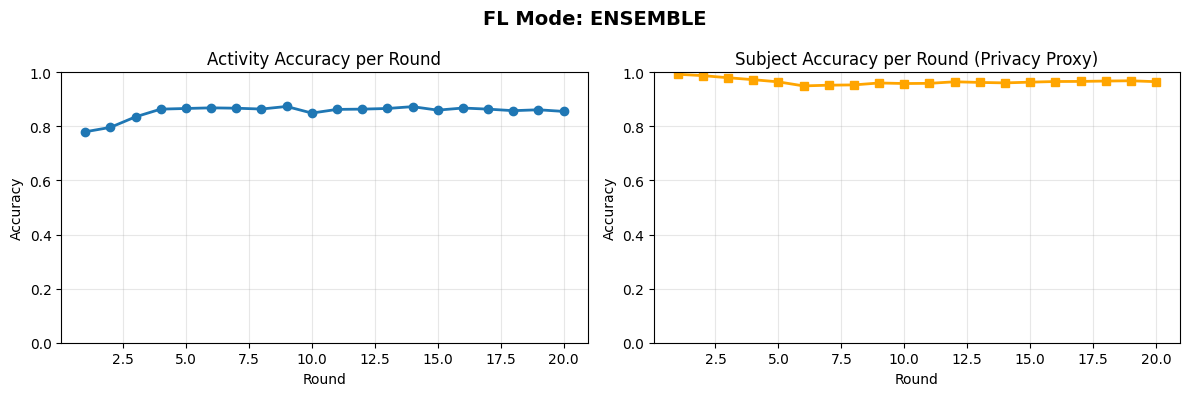


Final  act_acc  = 0.8554
Final  subj_acc = 0.9654


In [28]:
import matplotlib.pyplot as plt

rounds    = [h["round"]    for h in history]
act_accs  = [h["act_acc"]  for h in history]
subj_accs = [h["subj_acc"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rounds, act_accs, marker="o", linewidth=2)
axes[0].set_title("Activity Accuracy per Round")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

axes[1].plot(rounds, subj_accs, marker="s", color="orange", linewidth=2)
axes[1].set_title("Subject Accuracy per Round (Privacy Proxy)")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f"FL Mode: {config['mode'].upper()}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nFinal  act_acc  = {act_accs[-1]:.4f}")
print(f"Final  subj_acc = {subj_accs[-1]:.4f}")

In [31]:
import torch
import json

#Save ALL client models
for cid, model in server.client_models.items():
    torch.save(model.state_dict(), f"client_{cid}.pth")


# save history
with open("ensemble_history.json", "w") as f:
    json.dump(server.history, f)